In [1]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 

# Ensure CUDA is available and if not use CPU
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device found")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device.type == "cuda":
    torch.set_default_tensor_type(torch.cuda.FloatTensor)

# Set seed for reproducibility
torch.manual_seed(0)

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

Torch version: 2.4.1.post300
CUDA available: True
CUDA device count: 3
CUDA device name: NVIDIA L40S
Using device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0


<module 'BetaDirichletFactor.utils' from '/gpfs/commons/home/kisaev/Leaflet-private/src/BetaDirichletFactor/utils.py'>

In [2]:
# Anndata file input file path 
ATSE_anndata_file="/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/BRAIN_ONLY/02112025/TMS_Anndata_ATSE_counts_with_waypoints_20250211_171237.h5ad"
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/ATSEfiles/TMS_atse_file_unanno_also_2025-01-30_19-24-18.txt.gz"

# Define directory where output files should be saved 
output_dir="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/" 
# Make a directory for the output files inside the output directory with today's date, inside of that make a directory for the run with the current time
date=datetime.datetime.now().strftime("%Y-%m-%d")
time=datetime.datetime.now().strftime("%H-%M-%S")
output_dir = os.path.join(output_dir, date, time)

os.makedirs(output_dir, exist_ok=True)
print(f"All outputs will be saved in {output_dir}")

All outputs will be saved in /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/2025-02-20/18-07-11


In [3]:
db = gffutils.FeatureDB("/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/gencodeVM19", keep_order=True)

# Load splicing anndata file along with the ATSE annotation file (both obtained using upstream processing within LeafletFA framework)
adata = ad.read_h5ad(ATSE_anndata_file)
atses = pd.read_csv(ATSE_file, sep="\t")

In [4]:
# Convert string age group to integer
adata.obs["age_group"] = adata.obs["age"].str.replace("m", "").astype(int)

### Initialize and train the LeafletFA model!

In [5]:
# Set up some useful params 
input_conc = None #torch.tensor(np.inf) # can also set as torch.tensor(np.inf) for binomial likelihood or None (beta-binomial likelihood will be used)
junc_specific_prior = True # set to True if you want to use a junc-specific prior (a set of a,b shape params for each junction) or False to learn one set of a,b shape params for all junctions
K = 30
waypoints_use = True # make sure waypoint for PSI and PHI for specified K are included in the anndata object 
num_inits = 1
num_epochs = 150
cell_type_column = "cell_type_grouped"
linear_regression_columns = ["age_group"]
lr = 0.5
print_epochs = 10

Taking in the AnnData object with 19942 cells and 76811 junctions.
Processing AnnData on cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Random seeds: [8087]
Training LeafletFA with 1 initializations.
Input concentration prior: None
Junction-specific prior: True
Initial K to learn: 30
Initializing variational parameters with pre-defined PSI and PHI matrices!
Shape of PSI_init is torch.Size([30, 76811])
Shape of PHI_init is torch.Size([19942, 30])
-------------------------------------------------
Initialization #1 with seed 8087
-------------------------------------------------
Training in progress for 150 epochs!
Epoch 0: Loss = 363368476.1951452
Epoch 10: Loss = 252277907.341522
Epoch 20: Loss = 210768484.38118452
Epoch 30: Loss = 192144582.89172304
Epoch 40: Loss = 185411360.80496746
Epoch 50: Loss = 183481641.7630551
Epoch 60: Loss = 182796188.68181053
Epoch 70: Loss = 182424017.64590323
Epoch 80: Loss = 182223283.08248907
Epoch 90: Loss = 182097123.10497427
Epoch 100: Loss = 182004281.8285572
Epoch 110: Loss = 181922782.04515785
Epoch 120: Loss = 181868640.60634887
Epoch 130: Loss = 181822060.74440908
Epoch 140: Los

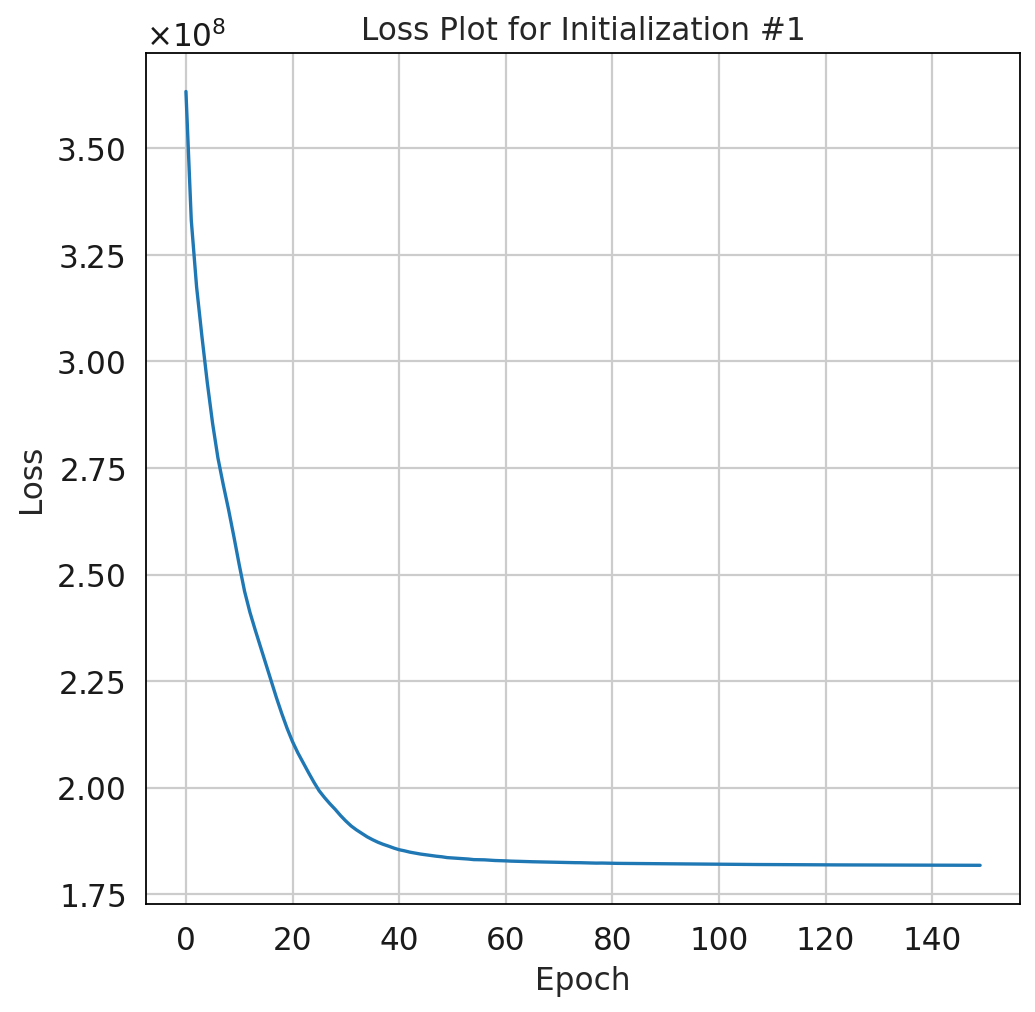

In [6]:
# Let's initialize the LeafletFA class 
leaflet_model = LeafletFA.LeafletFA(adata=adata, K=K, junc_specific_prior = junc_specific_prior, waypoints_use=waypoints_use, 
                           input_conc_prior = input_conc, num_epochs=num_epochs, print_epochs=print_epochs, 
                           ELBO_num_particles=5, 
                           lr=lr, gamma=0.05, num_samples=100)

# Convert AnnData into PyTorch tensors for model training 
leaflet_model.from_anndata()

# Train the model 
leaflet_model.train(num_initializations=num_inits)

# Get the best initialization and extract all the latent variables at this initialization
# If you want the latent variables from a different initialization, you can pass the index of that initialization to the get_all_variables() function
leaflet_model.get_all_variables()

In [7]:
# let's look at the results 
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in leaflet_model.latent_results]

# Calculate correlations between initializations if more than 2 
if num_inits > 1:
    avg_corr, median_corr, min_corr = utils.calculate_and_plot_correlations(assign_matrices)
else: 
    avg_corr, median_corr, min_corr = None, None, None  # Set default values when there's only one initialization

In [8]:
# Prune K: note this updates all the latent variables in the model to only include estimates for the pruned K
leaflet_model.prune_K()

The K before pruning is 30
The K after pruning is 21
Upating K to 21 in the LeafletFA object.


In [9]:
LEAFLETFA_LATENT_KEY = "X_leafletFA"
adata.obsm[LEAFLETFA_LATENT_KEY] = leaflet_model.assign_post # assign_post is the posterior assignment cell-factor activity matrix 

sc.pp.neighbors(adata, use_rep=LEAFLETFA_LATENT_KEY)
sc.tl.umap(adata)

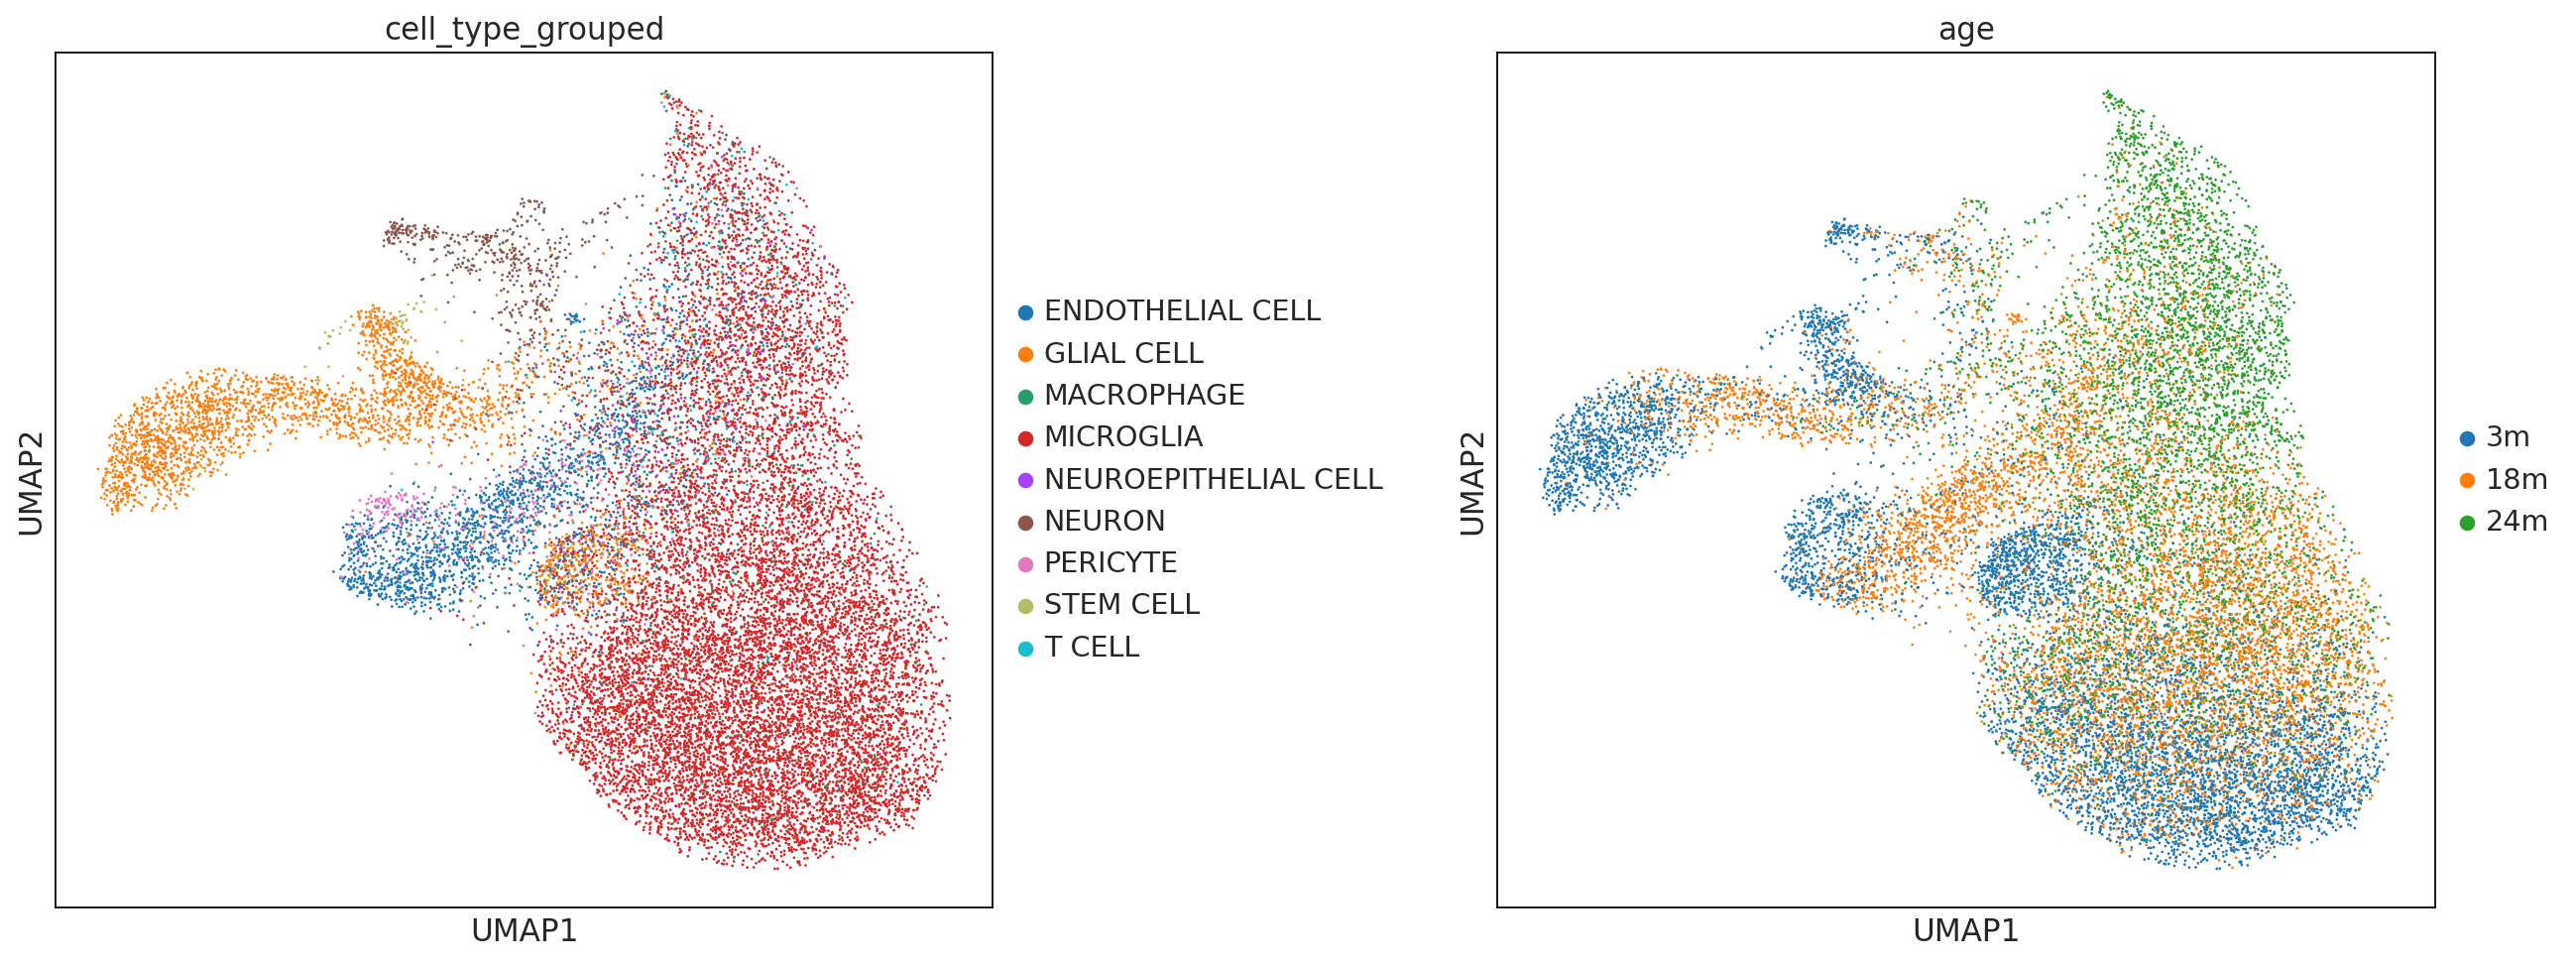

In [10]:
sc.pl.umap(adata, color=["cell_type_grouped", "age"], wspace=0.4)

In [11]:
cell_tye_silhouette = ds.calculate_silhouette_score(leaflet_model.assign_post, adata.obs.cell_type_grouped.values)
age_silhouette = ds.calculate_silhouette_score(leaflet_model.assign_post, adata.obs.age.values)

print(f"Silhouette score for cell types: {cell_tye_silhouette}")
print(f"Silhouette score for age: {age_silhouette}")

Silhouette score for cell types: 0.06413534947701165
Silhouette score for age: 0.019412243669494515


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


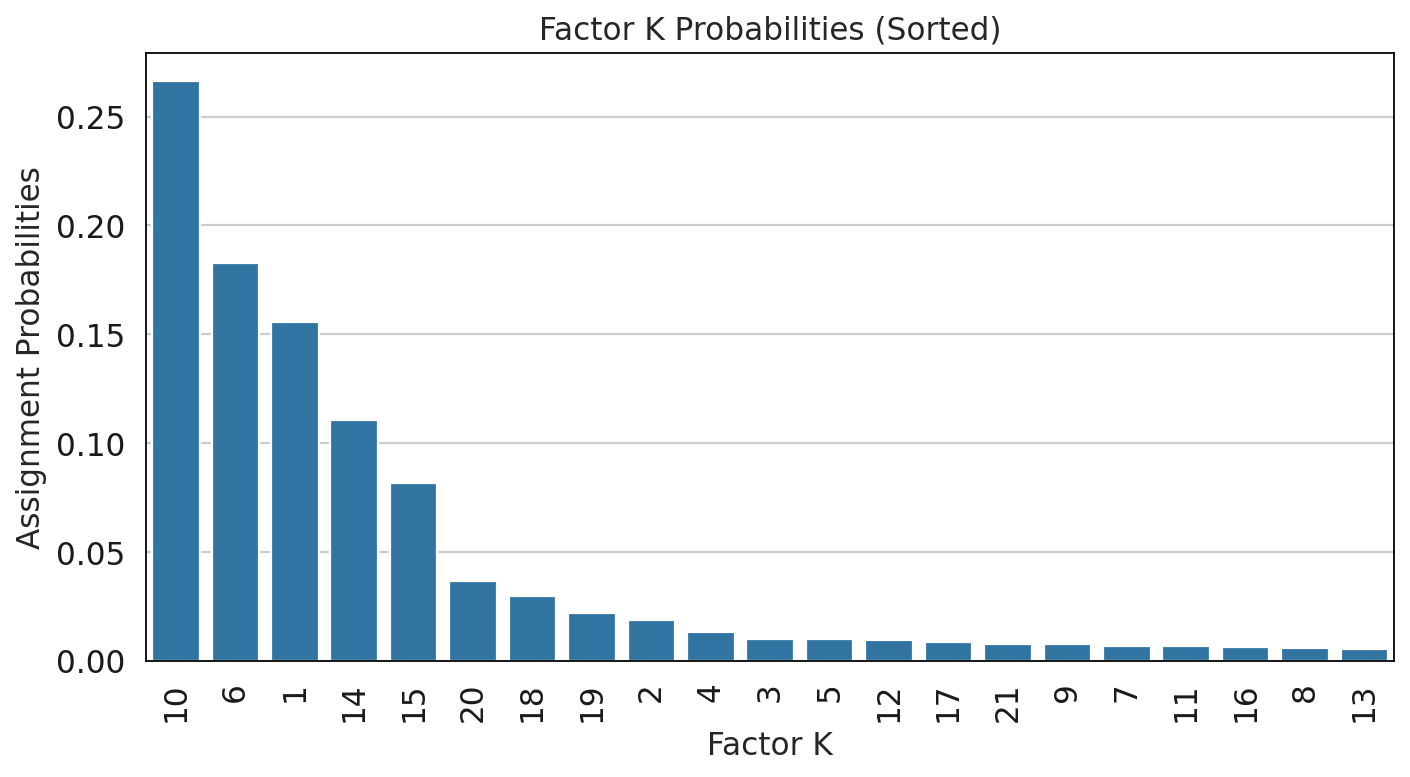

In [12]:
pi_df = pd.DataFrame(leaflet_model.pi, columns=["factor_assignment_probabilities"])
pi_df["factor_K"] = pi_df.index+1

# Sort by factor_assignment_probabilities in descending order
pi_df = pi_df.sort_values(by="factor_assignment_probabilities", ascending=False)

# Make sorted barplot
plt.figure(figsize=(10, 5))
sns.barplot(x="factor_K", y="factor_assignment_probabilities", data=pi_df, order=pi_df["factor_K"])
plt.title("Factor K Probabilities (Sorted)")
plt.xlabel("Factor K")
plt.ylabel("Assignment Probabilities")
plt.xticks(rotation=90)  # Rotate x-axis labels if many factors
plt.show()

The mean of the prior Beta distribution is 0.4987792218269939
The mean of the original Beta distribution is 0.5126169871576293


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


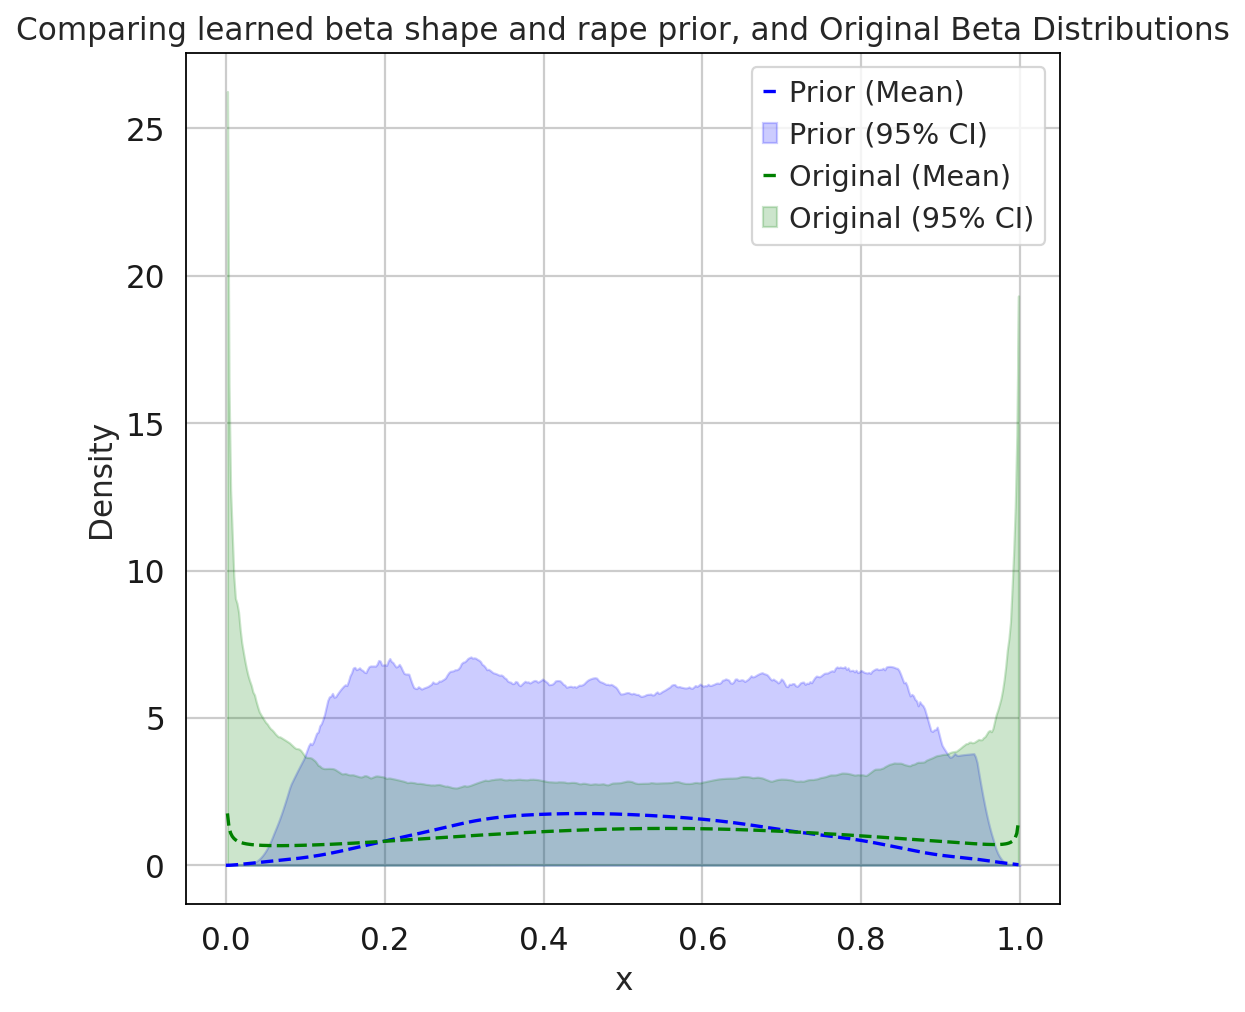

In [13]:
# Number of samples to capture variability
num_samples = 500  

# Sample multiple shape parameters for prior and original distributions which was ~ Gamma(2,2)
a_prior_samples = np.random.gamma(leaflet_model.a_shape, leaflet_model.a_rate, size=num_samples)
b_prior_samples = np.random.gamma(leaflet_model.a_shape, leaflet_model.a_rate, size=num_samples)

a_orig_samples = np.random.gamma(2, 2, size=num_samples)
b_orig_samples = np.random.gamma(2, 2, size=num_samples)

# Compute mean and confidence intervals for the Beta distributions
x = np.linspace(0, 1, num_samples)

# Compute PDFs for each sampled (a,b) pair
prior_pdfs = np.array([stats.beta.pdf(x, a, b) for a, b in zip(a_prior_samples, b_prior_samples)])
orig_pdfs = np.array([stats.beta.pdf(x, a, b) for a, b in zip(a_orig_samples, b_orig_samples)])

# Compute the mean and 95% confidence intervals for each x
prior_mean = np.mean(prior_pdfs, axis=0)
prior_lower = np.percentile(prior_pdfs, 2.5, axis=0)
prior_upper = np.percentile(prior_pdfs, 97.5, axis=0)

orig_mean = np.mean(orig_pdfs, axis=0)
orig_lower = np.percentile(orig_pdfs, 2.5, axis=0)
orig_upper = np.percentile(orig_pdfs, 97.5, axis=0)

print(f"The mean of the prior Beta distribution is {np.mean(a_prior_samples/(a_prior_samples+b_prior_samples))}")
print(f"The mean of the original Beta distribution is {np.mean(a_orig_samples/(a_orig_samples+b_orig_samples))}")

# Plot mean prior Beta distribution with confidence interval shading
plt.plot(x, prior_mean, label="Prior (Mean)", color='blue', linestyle='dashed')
plt.fill_between(x, prior_lower, prior_upper, color='blue', alpha=0.2, label="Prior (95% CI)")

# Plot mean original Beta distribution with confidence interval shading
plt.plot(x, orig_mean, label="Original (Mean)", color='green', linestyle='dashed')
plt.fill_between(x, orig_lower, orig_upper, color='green', alpha=0.2, label="Original (95% CI)")

# Labels and legend
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.title("Comparing learned beta shape and rape prior, and Original Beta Distributions")
plt.show()

/scratch/ipykernel_3554111/842995127.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", fontsize=8, ncol=2)  # Keep legend readable


The mean of the 0th factor's Beta distribution is: 0.0015445627504959702
The mean of the 1th factor's Beta distribution is: 0.3686510920524597
The mean of the 2th factor's Beta distribution is: 0.0011292713461443782
The mean of the 3th factor's Beta distribution is: 0.000894932949449867
The mean of the 4th factor's Beta distribution is: 0.004544471390545368
The mean of the 5th factor's Beta distribution is: 0.0011219936423003674
The mean of the 6th factor's Beta distribution is: 0.2854323089122772
The mean of the 7th factor's Beta distribution is: 0.0009353698114864528
The mean of the 8th factor's Beta distribution is: 0.0009330052998848259
The mean of the 9th factor's Beta distribution is: 0.0011892798356711864
The mean of the 10th factor's Beta distribution is: 0.3023791015148163
The mean of the 11th factor's Beta distribution is: 0.32161271572113037
The mean of the 12th factor's Beta distribution is: 0.0013388552470132709
The mean of the 13th factor's Beta distribution is: 0.0013778

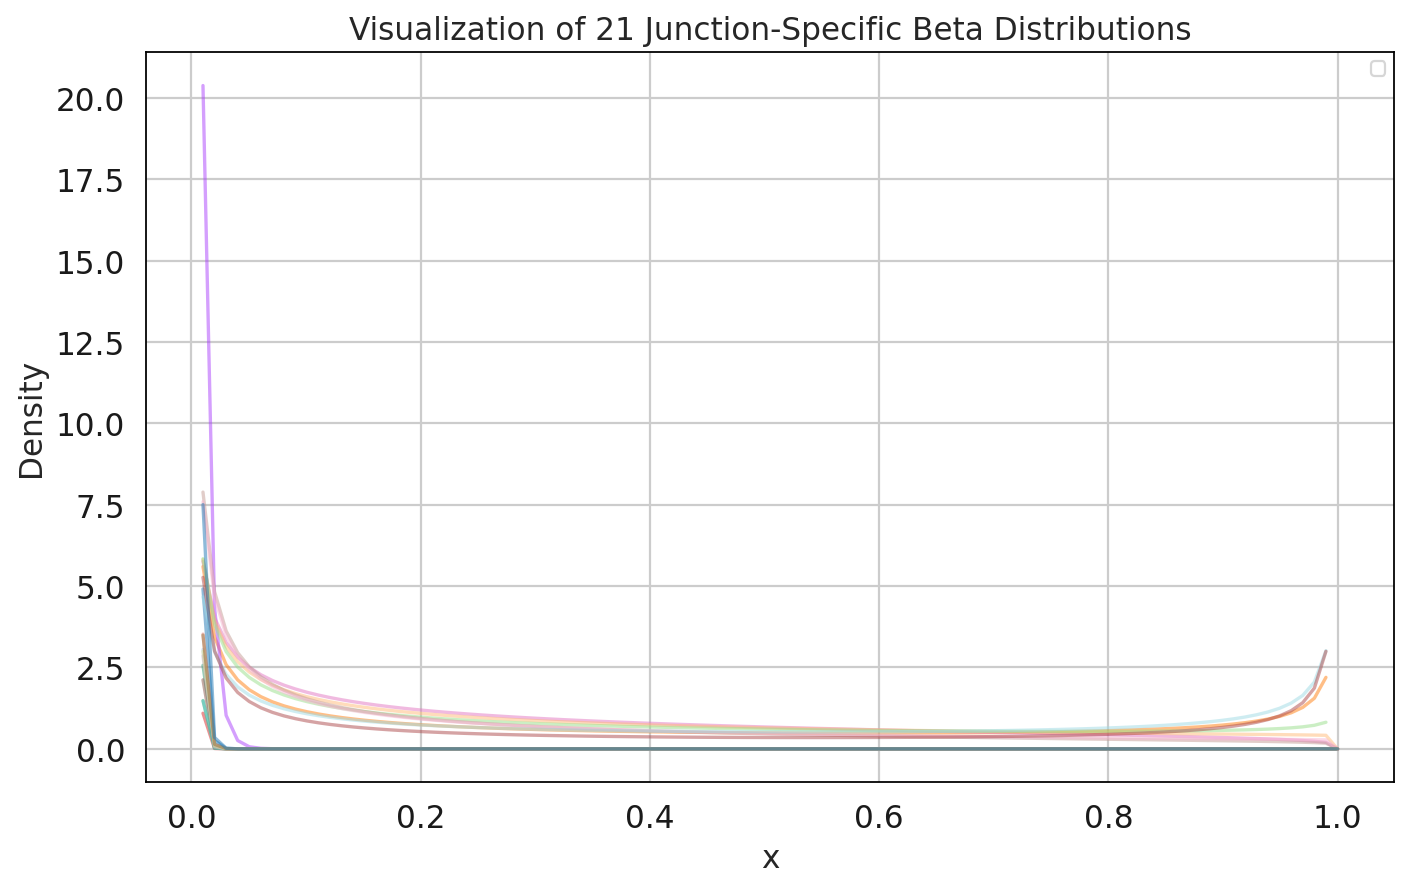

In [14]:
if junc_specific_prior:

    num_samples=100
    x = np.linspace(0, 1, num_samples)
    K = leaflet_model.K

    # Plot K Beta distributions, each corresponding to a junction's a and b
    plt.figure(figsize=(10, 6))
    for i in range(K):
        a_j = leaflet_model.a[i]
        b_j = leaflet_model.b[i]
        print(f"The mean of the {i}th factor's Beta distribution is: {a_j / (a_j + b_j)}")

        beta_pdf = stats.beta.pdf(x, a_j, b_j)
        plt.plot(x, beta_pdf, alpha=0.5)  

    # Labels and legend
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title(f"Visualization of {K} Junction-Specific Beta Distributions")
    plt.legend(loc="upper right", fontsize=8, ncol=2)  # Keep legend readable
    plt.show()

else:

    # sample from the learned prior on beta with leafletmodel.a and leafletmodel.b
    num_samples = 1000
    x = np.linspace(0, 1, num_samples)
    a = leaflet_model.a
    b = leaflet_model.b
    
    # sample from this beta distribution only one global a and b value... 
    beta_pdf = stats.beta.pdf(x, a, b)
    plt.plot(x, beta_pdf, label="Learned Beta Distribution")

### Differential splicing analysis

In [15]:
if K > 2:
    results = ds.analyze_all_factors(leaflet_model, fdr_threshold=0.05, min_effect_size=0.1)

    # Let's collect all the dataframes from results
    # go through results.keys() and collect second value in tuple and add column indicating factor K
    results_df = pd.DataFrame()
    for key in results.keys():
        factor_res = results[key][1]
        factor_res["factor_K"] = key
        results_df = pd.concat([results_df, factor_res])

    # for every unique junctions i want to summarize number of factors that it was significant in
    sig_only = results_df[results_df["significant"] == True]
    sig_only = sig_only.groupby("junction_idx").agg({"significant": "count"}).reset_index()
    sig_only = sig_only.rename(columns={"significant": "num_factors_significant"})
    # merge with results_df
    results_df = results_df.merge(sig_only, on="junction_idx", how="left")
    results_df["abs_effect_size"] = np.abs(results_df["effect_size"])

    # plot dist of effect sizes
    plt.figure(figsize=(6, 6))
    sns.histplot(results_df["effect_size"], bins=30)
    plt.xlabel("Effect Size")
    plt.ylabel("Frequency")
    # save to output_dir
    plt.savefig(os.path.join(output_dir, "effect_size_dist.png"))

Analyzing differential splicing for 21 factors...
Finding DS junctions in factor 0 vs. all others


 74%|███████▍  | 74/100 [37:29<13:10, 30.40s/it]


### Plot some ATSEs

In [ ]:
# # Visualize random ATSEs
atse_event = atses.sample(1)["event_id"].values[0]

juncs = atses[atses["event_id"]==atse_event]
juncs["usage_ratio"] = 0

juncs["Cluster"] = juncs["event_id"]
splice_junctions = ja.convert_junction_ids(juncs)

# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})


In [ ]:
# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start, region_end, base_width=8, trans_height=0.5, show_usage=False, show_junc_lines=True)
